In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv('../../outputs/df_engineered.csv', 
                  index_col='datetime', 
                  parse_dates=True)

In [60]:
df.columns

Index(['Temperature', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI',
       'Cloud Type', 'Relative Humidity', 'Pressure', 'Wind Direction',
       'Wind Speed', 'DHI', 'DNI', 'GHI', 'Solar Zenith Angle',
       'Precipitable Water', 'Surface Albedo', 'Fill Flag', 'Dew Point',
       'Asymmetry', 'Aerosol Optical Depth', 'Alpha', 'solar_zenith',
       'solar_elevation', 'ET_irradiance', 'hour_sin', 'hour_cos', 'doy_sin',
       'doy_cos', 'month', 'week_of_year', 'day_of_week', 'GHI_lag_1h',
       'GHI_lag_3h', 'GHI_lag_24h', 'temp_lag_1h', 'temp_lag_3h',
       'temp_lag_24h', 'humidity_lag_1h', 'humidity_lag_3h',
       'humidity_lag_24h', 'GHI_rollmean_3h', 'GHI_rollmean_6h',
       'GHI_rollmean_24h', 'GHI_rollstd_3h', 'GHI_rollstd_6h',
       'GHI_rollstd_24h', 'cloud_cover_proxy', 'humidity_x_temp',
       'cloud_x_elevation'],
      dtype='object')

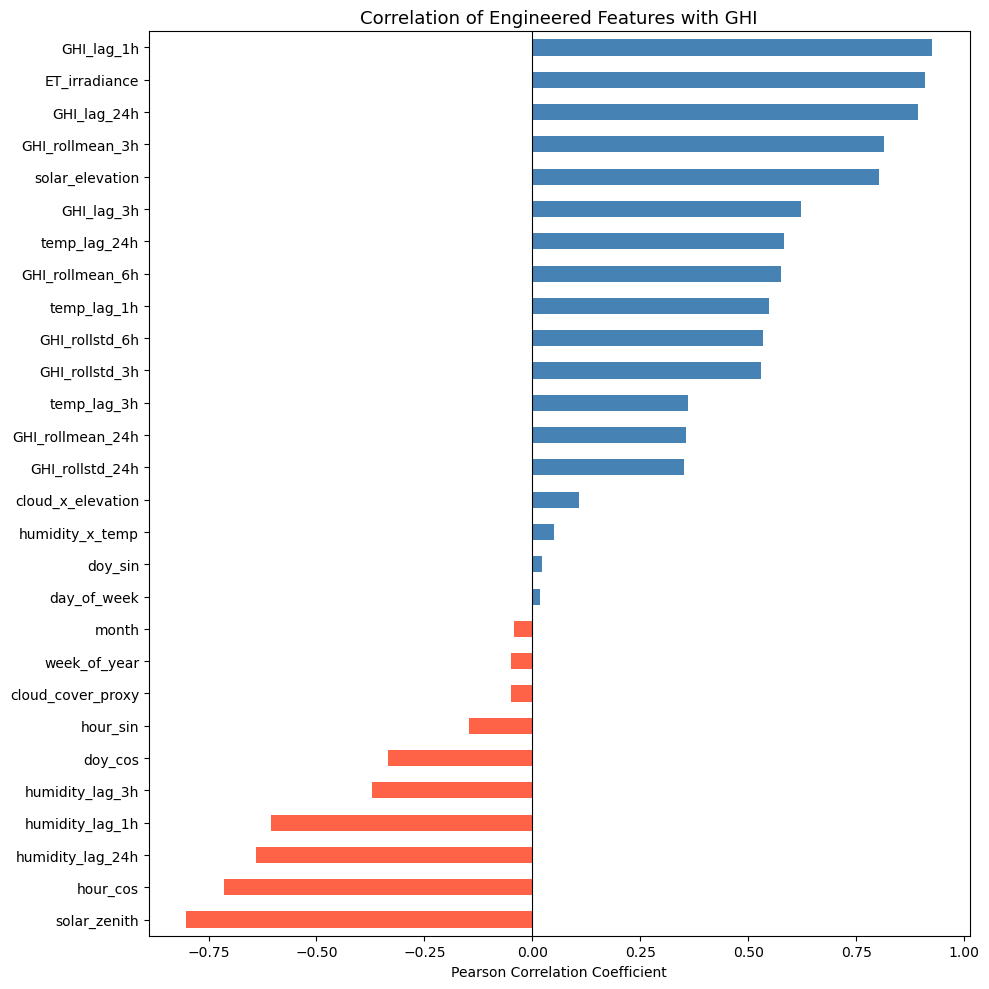

Top 5 positive correlations with GHI:
solar_elevation    0.802
GHI_rollmean_3h    0.814
GHI_lag_24h        0.893
ET_irradiance      0.910
GHI_lag_1h         0.926

Top 5 negative correlations with GHI:
solar_zenith       -0.802
hour_cos           -0.713
humidity_lag_24h   -0.639
humidity_lag_1h    -0.605
humidity_lag_3h    -0.372


In [29]:
# Correlation of each engineered feature with GHI only
cols_engineered = [
    # Task 1 - Solar geometry (3 features)
    'solar_zenith', 
    'solar_elevation', 
    'ET_irradiance',

    # Task 2 - Time features (7 features)
    'hour_sin', 
    'hour_cos', 
    'doy_sin', 
    'doy_cos', 
    'month',
    'week_of_year',
    'day_of_week',

    # Task 3 - Lag features (9 features)
    'GHI_lag_1h', 
    'GHI_lag_3h', 
    'GHI_lag_24h',
    'temp_lag_1h', 
    'temp_lag_3h', 
    'temp_lag_24h',
    'humidity_lag_1h', 
    'humidity_lag_3h', 
    'humidity_lag_24h',

    # Task 4 - Rolling stats (6 features)
    'GHI_rollmean_3h', 
    'GHI_rollmean_6h', 
    'GHI_rollmean_24h',
    'GHI_rollstd_3h',  
    'GHI_rollstd_6h',  
    'GHI_rollstd_24h',

    # Task 5 - Interactions (3 features)
    'cloud_cover_proxy', 
    'cloud_x_elevation', 
    'humidity_x_temp'
]
corr_with_ghi = df[cols_engineered + ['GHI']].corr()['GHI'].drop('GHI').sort_values()

plt.figure(figsize=(10, 10))
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_with_ghi.values]
corr_with_ghi.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlation of Engineered Features with GHI', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../../Outputs/correlation_with_ghi.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 positive correlations with GHI:')
print(corr_with_ghi.tail(5).round(3).to_string())
print('\nTop 5 negative correlations with GHI:')
print(corr_with_ghi.head(5).round(3).to_string())

In [31]:
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Missing values: {df.isnull().sum().sum()}')

Shape: (8736, 48)
Date range: 2022-01-02 00:30:00+01:00 to 2022-12-31 23:30:00+01:00
Missing values: 0


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred, y_train, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mse ** 0.5

    smape = (
        100
        * np.mean(
            2 * np.abs(y_pred - y_true)
            / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
        )
    )

    scale = np.mean(np.abs(np.diff(y_train)))
    mase = mae / scale if scale != 0 else np.nan

    return pd.DataFrame(
        {
            'Model': [model_name],
            'MSE': [mse],
            'MAE': [mae],
            'RMSE': [rmse],
            'sMAPE (%)': [smape],
            'MASE': [mase],
        }
    )

In [36]:
import statsmodels
print(statsmodels.__version__)

0.14.5


In [37]:
# Use only daytime hours for modelling (nighttime GHI is always 0, adds noise)
ghi = df['GHI']

# Train/test split — 80% train, 20% test (chronological)
split = int(len(ghi) * 0.8)
train = ghi.iloc[:split]
test  = ghi.iloc[split:]

print(f'Train: {len(train)} rows  ({train.index.min().date()} to {train.index.max().date()})')
print(f'Test:  {len(test)} rows   ({test.index.min().date()} to {test.index.max().date()})')

Train: 6988 rows  (2022-01-02 to 2022-10-20)
Test:  1748 rows   (2022-10-20 to 2022-12-31)


In [38]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value:       {result[1]:.4f}')
print(f'Stationary:    {result[1] < 0.05}')

ADF Statistic: -6.0573
p-value:       0.0000
Stationary:    True


In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

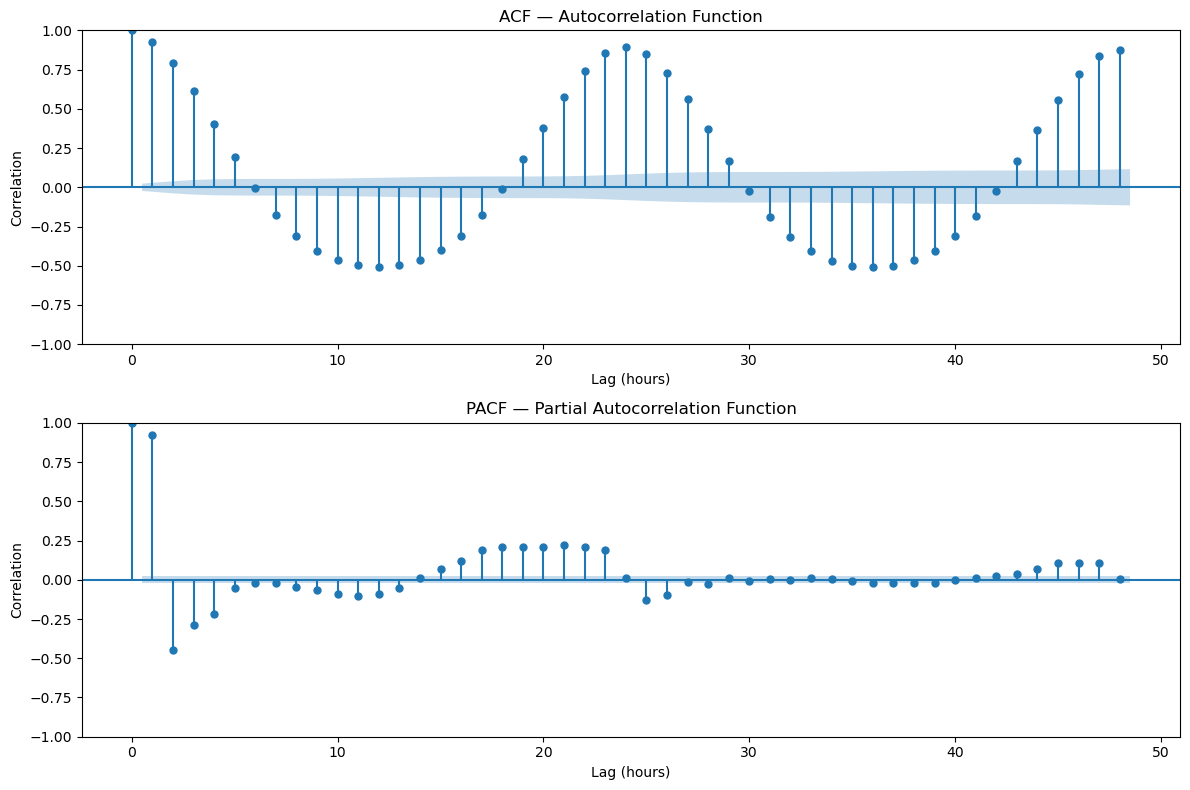

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(train, lags=48, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — Autocorrelation Function')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Correlation')

plot_pacf(train, lags=48, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — Partial Autocorrelation Function')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.savefig('../../outputs/acf_pacf.png', bbox_inches='tight', dpi=150)
plt.show()

In [45]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [46]:
# --- Baseline ARIMA ---
print('Fitting ARIMA(2,0,2)...')
model_arima = ARIMA(train, order=(2, 0, 2))
result_arima = model_arima.fit()

forecast_arima = result_arima.forecast(steps=len(test)).clip(lower=0)

Fitting ARIMA(2,0,2)...


In [47]:
# --- SARIMA ---
print('\nFitting SARIMA(2,0,2)(1,0,1,24)... this may take a few minutes')
model_sarima = SARIMAX(train, order=(2, 0, 2), seasonal_order=(1, 0, 1, 24))
result_sarima = model_sarima.fit(disp=False)

forecast_sarima = result_sarima.forecast(steps=len(test)).clip(lower=0)


Fitting SARIMA(2,0,2)(1,0,1,24)... this may take a few minutes


In [48]:
# Evaluate both models
results_arima  = evaluate_forecast(test, forecast_arima,  train, 'ARIMA(2,0,2)')
results_sarima = evaluate_forecast(test, forecast_sarima, train, 'SARIMA(2,0,2)(1,0,1,24)')

# Combine into one comparison table
results = pd.concat([results_arima, results_sarima], ignore_index=True)
print(results.to_string(index=False))

                  Model          MSE        MAE       RMSE  sMAPE (%)     MASE
           ARIMA(2,0,2) 38020.566612 185.615304 194.988632 157.455504 2.695114
SARIMA(2,0,2)(1,0,1,24) 24333.006254  86.223479 155.990404 144.544360 1.251955


In [61]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

features_for_ml = [
     'ET_irradiance',  
    'solar_elevation', 
    'Temperature'
]

# Split features chronologically same as train/test
X_train = df[features_for_ml].iloc[:split]
X_test  = df[features_for_ml].iloc[split:]

# Fit SARIMAX with engineered features
print('Fitting SARIMAX... this may take a few minutes')
model_sarimax = SARIMAX(train,
                         exog=X_train,
                         order=(5, 0, 1),
                         seasonal_order=(1, 1, 1, 24))
result_sarimax = model_sarimax.fit(disp=False)

forecast_sarimax = result_sarimax.forecast(steps=len(test),
                                            exog=X_test).clip(lower=0)

results_sarimax = evaluate_forecast(test, forecast_sarimax, train, 'SARIMAX(5,0,1)(1,1,1,24)')

# Full comparison
results = pd.concat([results_arima, results_sarima, results_sarimax], ignore_index=True)
print(results.to_string(index=False))


Fitting SARIMAX... this may take a few minutes
                   Model          MSE        MAE       RMSE  sMAPE (%)     MASE
            ARIMA(2,0,2) 38020.566612 185.615304 194.988632 157.455504 2.695114
 SARIMA(2,0,2)(1,0,1,24) 24333.006254  86.223479 155.990404 144.544360 1.251955
SARIMAX(5,0,1)(1,1,1,24)  8273.104963  44.217808  90.956610  39.871568 0.642038


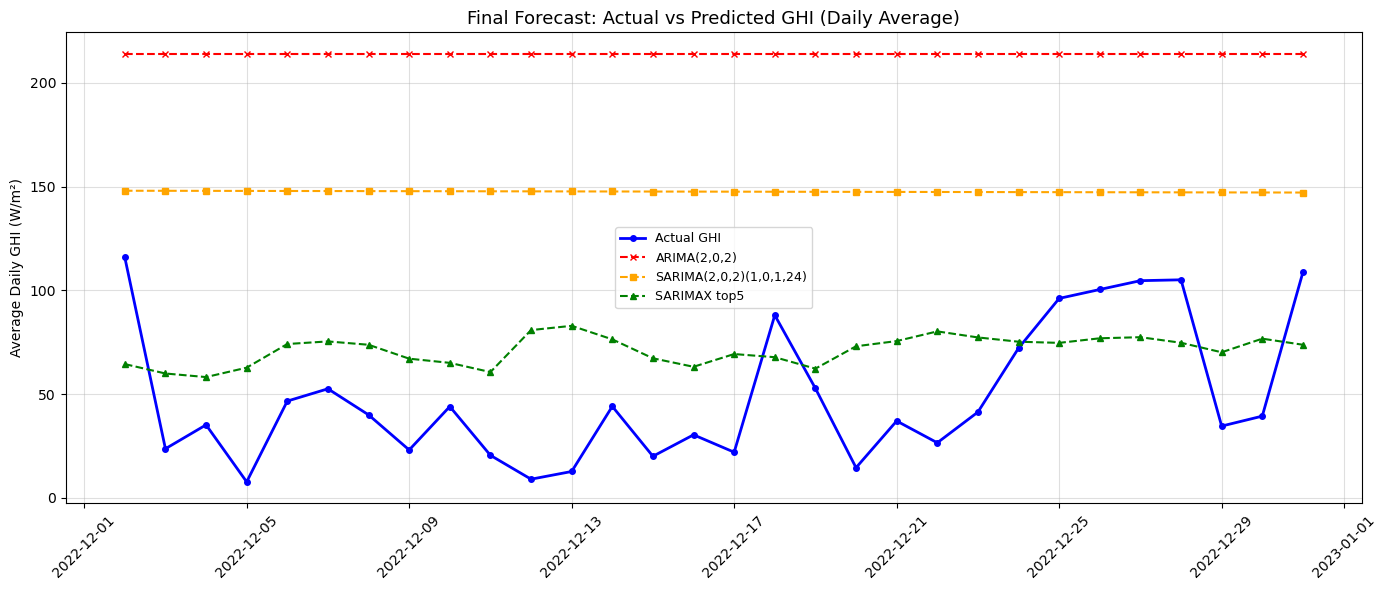

In [62]:
# Combine actual and forecasts into one dataframe
compare_df = pd.DataFrame({
    'Actual':  test,
    'ARIMA':   forecast_arima,
    'SARIMA':  forecast_sarima,
    'SARIMAX': forecast_sarimax
}, index=test.index)

# Resample to daily average
compare_daily = compare_df.resample('D').mean()

# Plot last 30 days
plot_df = compare_daily.iloc[-30:]

plt.figure(figsize=(14, 6))

plt.plot(plot_df.index, plot_df['Actual'],
         color='blue',     lw=2,   marker='o', markersize=4, label='Actual GHI')
plt.plot(plot_df.index, plot_df['ARIMA'],
         color='red',      lw=1.5, marker='x', markersize=4, linestyle='--', label='ARIMA(2,0,2)')
plt.plot(plot_df.index, plot_df['SARIMA'],
         color='orange',   lw=1.5, marker='s', markersize=4, linestyle='--', label='SARIMA(2,0,2)(1,0,1,24)')
plt.plot(plot_df.index, plot_df['SARIMAX'],
         color='green',    lw=1.5, marker='^', markersize=4, linestyle='--', label='SARIMAX top5')

plt.title('Final Forecast: Actual vs Predicted GHI (Daily Average)', fontsize=13)
plt.ylabel('Average Daily GHI (W/m²)')
plt.xlabel('')
plt.legend(fontsize=9)
plt.grid(alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../outputs/forecast_final.png', bbox_inches='tight', dpi=150)
plt.show()